In [4]:
#importing libraries
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import warnings
warnings.filterwarnings("ignore")

In [5]:
import joblib
#Load saved model
model = joblib.load("intrusion_model.pkl")
#Load preprocessing pipeline
pipeline = joblib.load("numeric_pipeline.pkl")
print("Model and pipeline loaded successfully")

Model and pipeline loaded successfully


In [6]:
import pandas as pd

COL_NAMES = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty_level'
]

In [7]:
#Load Dataset
train_path="./data/KCDTrain.txt"
test_path="./data/KCDTest.txt"
df_train=pd.read_csv(train_path, header=None, names=COL_NAMES)
df_test=pd.read_csv(test_path, header=None, names=COL_NAMES)
print("Training Data Shape:", df_train.shape)
print("Testing Data Shape:", df_test.shape)
df_raw = df_train.copy()
print("Raw Data Shape:", df_raw.shape)

Training Data Shape: (125973, 43)
Testing Data Shape: (22544, 43)
Raw Data Shape: (125973, 43)


In [8]:
#Preparing test data
X_test = df_test.drop(columns=['label'])
categorical_cols = ['protocol_type', 'service', 'flag']
X_encoded = pd.get_dummies(X_test, columns=categorical_cols)
#Aligning columns
train_columns = model.feature_names_in_
X_encoded = X_encoded.reindex(columns=train_columns, fill_value=0)
print("Data ready")

Data ready


In [9]:
le = joblib.load("label_encoder.pkl")

In [10]:
#testing prediction
for i in range(5):
    row = X_encoded.iloc[i:i+1]
    pred = model.predict(row)[0]

    attack = le.inverse_transform([pred])[0]
    print(f"Row {i} → {attack}")

Row 0 → DoS
Row 1 → DoS
Row 2 → normal
Row 3 → Probe
Row 4 → Probe


In [11]:
from datetime import datetime
import pandas as pd
logs = []
print("\n--- Real-Time Intrusion Detection ---\n")
MAX_ROWS = 100
for i in range(min(MAX_ROWS, len(X_encoded))):
    
    row = X_encoded.iloc[i:i+1]
    pred = model.predict(row)[0]

    attack = le.inverse_transform([pred])[0]
    current_time = datetime.now().strftime("%H:%M:%S")

    if attack != "normal":
        status = "INTRUSION DETECTED"
        print(f"[{current_time}] Row {i} → {attack} → {status}")
    else:
        status = "Normal"

    logs.append({
        "time": current_time,
        "row": i,
        "attack": attack,
        "status": status
    })

print("\n Simulation completed!")


--- Real-Time Intrusion Detection (FAST DEMO) ---

[23:43:53] Row 0 → DoS → INTRUSION DETECTED
[23:43:53] Row 1 → DoS → INTRUSION DETECTED
[23:43:53] Row 3 → Probe → INTRUSION DETECTED
[23:43:53] Row 4 → Probe → INTRUSION DETECTED
[23:43:54] Row 12 → DoS → INTRUSION DETECTED
[23:43:54] Row 13 → DoS → INTRUSION DETECTED
[23:43:54] Row 19 → DoS → INTRUSION DETECTED
[23:43:54] Row 20 → DoS → INTRUSION DETECTED
[23:43:54] Row 21 → DoS → INTRUSION DETECTED
[23:43:54] Row 24 → DoS → INTRUSION DETECTED
[23:43:54] Row 25 → DoS → INTRUSION DETECTED
[23:43:54] Row 28 → DoS → INTRUSION DETECTED
[23:43:54] Row 33 → Probe → INTRUSION DETECTED
[23:43:54] Row 34 → Probe → INTRUSION DETECTED
[23:43:54] Row 37 → U2R → INTRUSION DETECTED
[23:43:55] Row 40 → DoS → INTRUSION DETECTED
[23:43:55] Row 44 → DoS → INTRUSION DETECTED
[23:43:55] Row 46 → DoS → INTRUSION DETECTED
[23:43:55] Row 47 → DoS → INTRUSION DETECTED
[23:43:55] Row 48 → DoS → INTRUSION DETECTED
[23:43:55] Row 52 → DoS → INTRUSION DETECTED

In [12]:
#Convert logs list to DataFrame
log_df = pd.DataFrame(logs)
#Save logs to CSV file
log_df.to_csv("intrusion_logs.csv", index=False)
print("Logs saved successfully!")

Logs saved successfully!


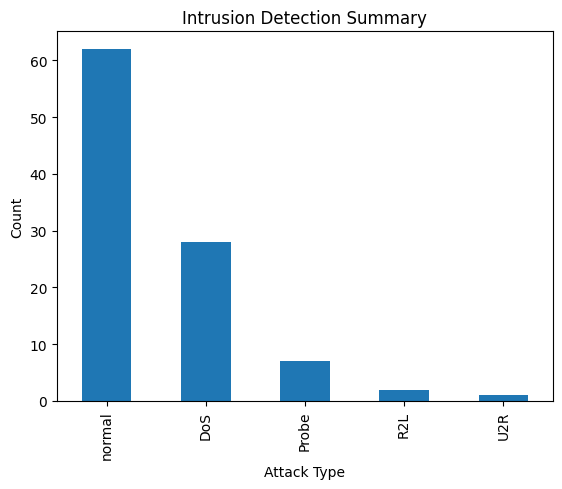

In [13]:
import matplotlib.pyplot as plt
#Count occurrences of each attack type
log_df['attack'].value_counts().plot(kind='bar')
#Add titles and labels
plt.title("Intrusion Detection Summary")
plt.xlabel("Attack Type")
plt.ylabel("Count")
#Show graph
plt.show()

In [14]:
#This code simulates real-time intrusion detection using a trained machine learning model.
#It processes up to 100 network records to ensure fast execution and mimic real-time data flow.
#For each record, it predicts the attack type, generates alerts for intrusions,
#and stores the results as logs for further analysis.